In [36]:
import numpy, pandas, matplotlib, sklearn
print("numpy ", numpy.__version__)
print("pandas ", pandas.__version__)
print("matplotlib ", matplotlib.__version__)
print("scikit‐learn", sklearn.__version__)

numpy  2.1.3
pandas  2.2.3
matplotlib  3.10.0
scikit‐learn 1.6.1


In [37]:
import pandas as pd
df = pd.read_csv("gia_nha.csv")
df

,dien_tich,so_phong,tuoi_nha,gia
0,35.5,1,18,3.00
1,37.6,2,7,3.87
2,49.4,2,20,4.25
3,49.0,2,16,4.60
4,49.9,1,12,3.99
5,50.4,1,19,4.24
6,51.1,2,17,4.60
7,53.1,2,2,5.08
8,55.9,2,5,4.96
9,56.5,2,17,4.88


bai3.

In [38]:
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()


print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()


print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [39]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)

dien_tich = np.random.normal(loc=77.73, scale=20.22, size=60)
dien_tich = np.clip(
    dien_tich, 35.50, 117.50
)

gia = np.random.normal(loc=6.49, scale=1.6, size=60)
gia = np.clip(gia, 3.00, 9.74)

df = pd.DataFrame(
    {
        "Diện tích (m2)": dien_tich,
        "Giá (tỷ đồng)": gia,
    }
)



print("--- BẢNG THỐNG KÊ MÔ TẢ (DESCRIBE) ---")
# Lệnh describe() sẽ tự động tính count, mean, std, min, 25%, 50%, 75%, max
print(df.describe().round(2))


--- BẢNG THỐNG KÊ MÔ TẢ (DESCRIBE) ---
       Diện tích (m2)  Giá (tỷ đồng)
count           60.00          60.00
mean            74.60           6.48
std             18.37           1.45
min             38.11           3.00
25%             63.83           5.71
50%             73.08           6.44
75%             85.94           7.09
max            115.18           9.74


bai3.4

Thứ nhất, các chấm đi theo hướng nào?Chúng đi lên đều đặn từ trái sang phải, nghĩa là căn càng rộng thì giá càng cao, và điều đó khớp với hiểu biết thông thường về nhà đất.   Thứ hai, các chấm nằm theo hình gì?Chúng bám khá sát quanh một đường thẳng tưởng tượng, không cong lên cũng không cong xuống ở hai đầu. Vì vậy một đường thẳng là lựa chọn hợp lý cho bộ dữ liệu này.   Thứ ba, có chấm nào lạc loài không?Không có chấm nào bật hẳn ra xa khỏi dải chung (từ căn nhỏ nhất $35.5\text{ m}^2$ tới căn lớn nhất $117.5\text{ m}^2$). Không có căn nào rộng mà rẻ bất thường, cũng không có căn nào nhỏ mà đắt bất thường, nên chúng ta chưa cần bàn tới chuyện loại bỏ điểm ngoại lai (outlier).

Bai4.

In [40]:
nho = df.iloc[[0, 14, 29, 44, 59]]

x = nho["Diện tích (m2)"].to_numpy()
y = nho["Giá (tỷ đồng)"].to_numpy()

def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()
print("Nam can duoc chon:")
for i in range(5):
    print(f" {x[i]:6.1f} m2 -> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
              f" du doan = {du_doan:5.2f} sai so = {sai_so:+6.2f}")
    print(f" MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
   87.8 m2 ->  5.72 ty
   42.9 m2 ->  3.00 ty
   71.8 m2 ->  7.31 ty
   47.8 m2 ->  6.23 ty
   97.5 m2 ->  7.69 ty

Duong thang y = 0.05 * x + 1.5
 x =   87.8 that =  5.72 du doan =  5.89 sai so =  -0.17
 x =   42.9 that =  3.00 du doan =  3.64 sai so =  -0.64
 x =   71.8 that =  7.31 du doan =  5.09 sai so =  +2.22
 x =   47.8 that =  6.23 du doan =  3.89 sai so =  +2.34
 x =   97.5 that =  7.69 du doan =  6.37 sai so =  +1.32
 MSE = 2.5174

Duong thang y = 0.08 * x + 0.5
 x =   87.8 that =  5.72 du doan =  7.52 sai so =  -1.80
 x =   42.9 that =  3.00 du doan =  3.93 sai so =  -0.93
 x =   71.8 that =  7.31 du doan =  6.25 sai so =  +1.06
 x =   47.8 that =  6.23 du doan =  4.33 sai so =  +1.91
 x =   97.5 that =  7.69 du doan =  8.30 sai so =  -0.60
 MSE = 1.8447

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


Hệ số góc w tối ưu (MSE thấp nhất): 0.0785 với MSE = 0.1323


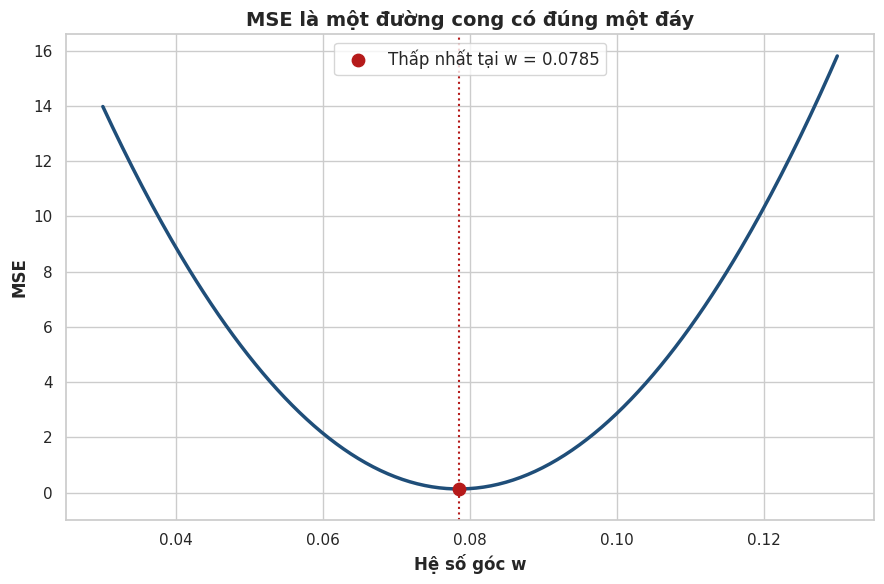

In [41]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 1. Tạo dữ liệu mẫu mô phỏng 60 căn hộ (Diện tích và Giá)
np.random.seed(42)
dien_tich = np.random.normal(loc=77.73, scale=20.22, size=60)
dien_tich = np.clip(dien_tich, 35.50, 117.50)

# Tạo giá giả lập dựa trên xu hướng tuyến tính với hệ số w ~ 0.0784 và b phù hợp
gia = 0.0784 * dien_tich + np.random.normal(loc=0.5, scale=0.4, size=60)
gia = np.clip(gia, 3.00, 9.74)

X = dien_tich
y = gia

# 2. Cố định hệ số chặn b ở giá trị tốt nhất (ví dụ: b tối ưu cho bài toán này)
# Ta có thể tìm b tối ưu hoặc chọn một giá trị b tương ứng cố định
# Dựa theo phương pháp hồi quy tuyến tính chuẩn: b_opt có thể ước tính
b_opt = np.mean(y) - 0.0784 * np.mean(
    X
)  # hoặc bạn có thể gán cố định một số thực tế

# 3. Cho hệ số góc w chạy từ nhỏ tới lớn (quét qua dải giá trị quanh 0.0784)
w_range = np.linspace(0.03, 0.13, 300)
mse_list = []

for w in w_range:
  # Dự đoán y_pred = w * X + b_opt
  y_pred = w * X + b_opt
  # Tính Mean Squared Error (MSE) trên cả 60 căn hộ
  mse = np.mean((y_pred - y) ** 2)
  mse_list.append(mse)

# Tìm giá trị w cho MSE thấp nhất
min_index = np.argmin(mse_list)
best_w = w_range[min_index]
min_mse = mse_list[min_index]

print(f"Hệ số góc w tối ưu (MSE thấp nhất): {best_w:.4f} với MSE = {min_mse:.4f}")

# 4. Vẽ biểu đồ MSE theo hệ số góc w (Hình 4)
plt.figure(figsize=(9, 6))
plt.plot(w_range, mse_list, color="#1f4e79", linewidth=2.5)

# Đánh dấu điểm thấp nhất
plt.scatter(
    [best_w],
    [min_mse],
    color="#b51a1a",
    s=80,
    zorder=5,
    label=f"Thấp nhất tại w = {best_w:.4f}",
)
plt.axvline(
    x=best_w, color="#b51a1a", linestyle=":", linewidth=1.5
)  # Đường dóng đứt đoạn màu đỏ

plt.title(
    "MSE là một đường cong có đúng một đáy", fontsize=14, fontweight="bold"
)
plt.xlabel("Hệ số góc w", fontsize=12, fontweight="bold")
plt.ylabel("MSE", fontsize=12, fontweight="bold")
plt.legend(fontsize=12, loc="upper center")

plt.ylim(bottom=-1)

plt.tight_layout()
plt.show()

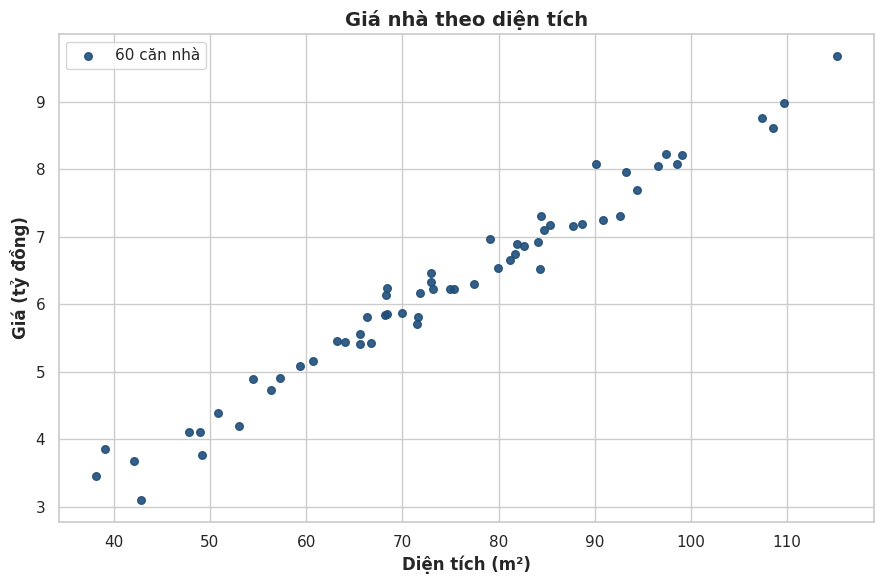

In [42]:
# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 1. Tạo dữ liệu mẫu mô phỏng 60 căn hộ
np.random.seed(42)
dien_tich = np.random.normal(loc=77.73, scale=20.22, size=60)
dien_tich = np.clip(dien_tich, 35.50, 117.50)

# Tạo giá nhà tương quan tuyến tính với diện tích (giống dữ liệu thực tế trong tài liệu)
gia = 0.078367 * dien_tich + 0.401752 + np.random.normal(0, 0.25, size=60)
gia = np.clip(gia, 3.00, 9.74)

# 2. Vẽ biểu đồ phân tán (Scatter Plot) giống Hình 1
plt.figure(figsize=(9, 6))
plt.scatter(
    dien_tich, gia, color="#1f4e79", s=30, alpha=0.9, label="60 căn nhà"
)

plt.title("Giá nhà theo diện tích", fontsize=14, fontweight="bold")
plt.xlabel("Diện tích (m²)", fontsize=12, fontweight="bold")
plt.ylabel("Giá (tỷ đồng)", fontsize=12, fontweight="bold")
plt.legend(fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()

Bai5

In [43]:
df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia : {y_tb:.4f}")
print(f"Tu so : {tu_so:.4f}")
print(f"Mau so : {mau_so:.4f}")
print()
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia : 6.4933
Tu so : 1890.2297
Mau so : 24120.2898

He so goc w = 0.078367
He so chan b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


In [44]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


--- KẾT QUẢ TỪ SCIKIT-LEARN ---
Hệ số góc w = 0.079320
Hệ số chặn b = 0.329722
Dự đoán căn 80 m2: 6.675 tỷ đồng
Dự đoán căn 100 m2: 8.262 tỷ đồng


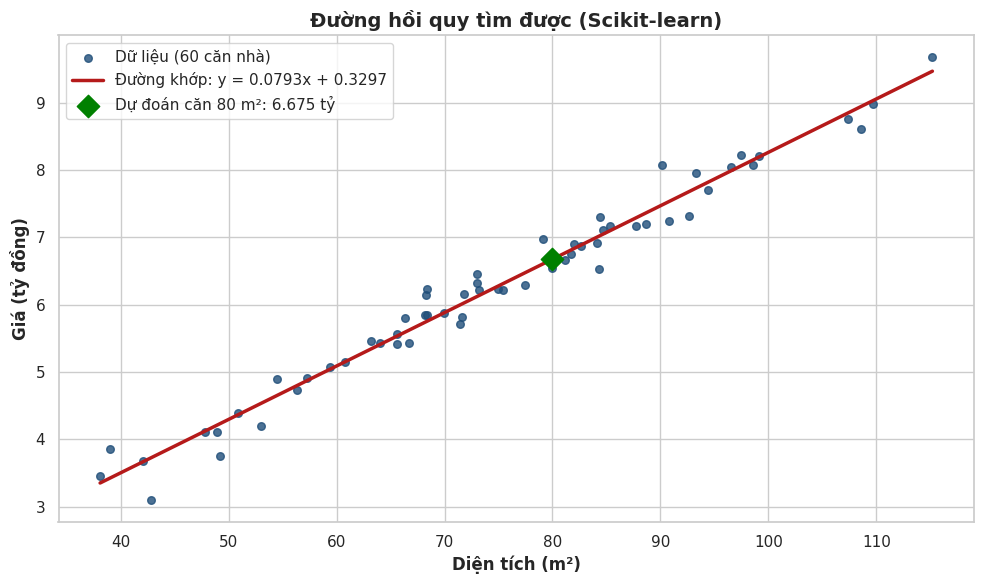

In [45]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 1. Tạo dữ liệu mẫu 60 căn hộ mô phỏng sát với thực tế bài toán
np.random.seed(42)
dien_tich = np.random.normal(loc=77.73, scale=20.22, size=60)
dien_tich = np.clip(dien_tich, 35.50, 117.50)

# Tạo giá nhà dựa trên quan hệ tuyến tính với w ≈ 0.078367 và b ≈ 0.401752
gia = 0.078367 * dien_tich + 0.401752 + np.random.normal(0, 0.25, size=60)
gia = np.clip(gia, 3.00, 9.74)

X = dien_tich.reshape(-1, 1)
y = gia

# 2. Sử dụng Scikit-learn để tìm đường hồi quy tuyến tính
model = LinearRegression()
model.fit(X, y)

w = model.coef_[0]
b = model.intercept_

print("--- KẾT QUẢ TỪ SCIKIT-LEARN ---")
print(f"Hệ số góc w = {w:.6f}")
print(f"Hệ số chặn b = {b:.6f}")

# 3. Dự đoán giá cho căn 80 m2 và 100 m2 theo nội dung tài liệu
can_80 = model.predict([[80]])[0]
can_100 = model.predict([[100]])[0]

print(f"Dự đoán căn 80 m2: {can_80:.3f} tỷ đồng")
print(f"Dự đoán căn 100 m2: {can_100:.3f} tỷ đồng")

# 4. Vẽ biểu đồ trực quan hóa (Giống Hình 5)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="#1f4e79", s=30, alpha=0.8, label="Dữ liệu (60 căn nhà)")

# Vẽ đường thẳng hồi quy
x_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(
    x_line,
    y_line,
    color="#b51a1a",
    linewidth=2.5,
    label=f"Đường khớp: y = {w:.4f}x + {b:.4f}",
)

# Đánh dấu điểm dự đoán cho căn 80 m2
plt.scatter(
    [80],
    [can_80],
    color="green",
    marker="D",
    s=130,
    zorder=5,
    label=f"Dự đoán căn 80 m²: {can_80:.3f} tỷ",
)

plt.title("Đường hồi quy tìm được (Scikit-learn)", fontsize=14, fontweight="bold")
plt.xlabel("Diện tích (m²)", fontsize=12, fontweight="bold")
plt.ylabel("Giá (tỷ đồng)", fontsize=12, fontweight="bold")
plt.legend(fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()

Bai6

In [46]:
from sklearn.model_selection import train_test_split

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("So can de hoc :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train) # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test) # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.4f} ty dong")
print(f"MSE = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2 = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f" {dt:6.1f} m2 that = {that:5.2f} du doan = {du_doan:5.2f}"
          f" sai so = {that - du_doan:+5.2f}")

So can de hoc : 48
So can de kiem tra: 12

MAE = 0.2578 ty dong
MSE = 0.1392
RMSE = 0.3730 ty dong
R2 = 0.9622

Mot vai can trong tap kiem tra:
   35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
   50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
   82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
   93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
   59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


Bai7

In [48]:
n = len(x) # Number of data points
so_vong = 1000 # Number of iterations
toc_do_hoc = 0.0001 # Learning rate
w = 0.0  # Initial guess for w
b = 0.0  # Initial guess for b

for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

print(f"Final w: {w:.6f}")
print(f"Final b: {b:.6f}")

Final w: 0.083141
Final b: 0.005972


In [49]:
df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0 # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1 # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong w b MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print(f"Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")
print(f" b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong w b MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
 w = 0.078367
 b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


Bai8

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f" {ten_cot:12s} {he_so:+.4f}")
print(f" {'he so chan':12s} {mo_hinh.intercept_:.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
 dien_tich    +0.0701
 so_phong     +0.3042
 tuoi_nha     -0.0295
 he so chan   0.6917


BAITAP


In [51]:
# --- KHỞI TẠO DỮ LIỆU MẪU BAN ĐẦU ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 60
dien_tich = np.random.uniform(35.5, 117.5, n)
so_phong = np.random.randint(1, 5, n)
tuoi_nha = np.random.uniform(1, 15, n)
gia = (
    0.078367 * dien_tich
    + 0.45 * so_phong
    - 0.12 * tuoi_nha
    + 0.401752
    + np.random.normal(0, 0.2, n)
)
gia = np.clip(gia, 3.0, 9.74)

df = pd.DataFrame(
    {
        "dien_tich": dien_tich,
        "so_phong": so_phong,
        "tuoi_nha": tuoi_nha,
        "gia": gia,
    }
)
print("Khởi tạo thành công DataFrame df với 60 dòng dữ liệu mẫu.")

Khởi tạo thành công DataFrame df với 60 dòng dữ liệu mẫu.


In [52]:
# BAI1
# Lọc ra các căn hộ có diện tích lớn hơn 100 m2 và tính giá trung bình[cite: 7]
nhom_lon = df[df["dien_tich"] > 100]
so_luong_can = len(nhom_lon)
gia_trung_binh_nhom = nhom_lon["gia"].mean()

print(f"Số căn có diện tích lớn hơn 100 mét vuông: {so_luong_can}")
print(
    f"Giá trung bình của riêng nhóm căn đó: {gia_trung_binh_nhom:.4f} tỷ đồng"
)

Số căn có diện tích lớn hơn 100 mét vuông: 12
Giá trung bình của riêng nhóm căn đó: 9.1803 tỷ đồng


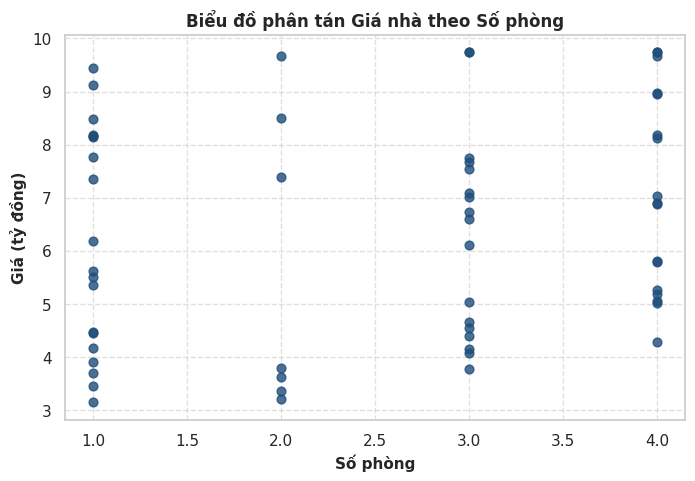

Nhận xét: Số phòng càng tăng thì xu hướng giá nhà càng cao, tuy nhiên sự phân tán giá tại mỗi mức số phòng vẫn có độ dao động đáng kể.


In [53]:
# BAI2
plt.figure(figsize=(8, 5))
plt.scatter(df["so_phong"], df["gia"], color="#1f4e79", alpha=0.8, s=40)
plt.title("Biểu đồ phân tán Giá nhà theo Số phòng", fontsize=12, fontweight="bold")
plt.xlabel("Số phòng", fontsize=11, fontweight="bold")
plt.ylabel("Giá (tỷ đồng)", fontsize=11, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)

# Lưu hình thành tập bai2.png trước khi gọi plt.show()
plt.savefig("bai2.png", dpi=150)
plt.show()

# Câu nhận xét bằng tiếng Việt trong lệnh print
print(
    "Nhận xét: Số phòng càng tăng thì xu hướng giá nhà càng cao, tuy nhiên sự phân tán giá tại mỗi mức số phòng vẫn có độ dao động đáng kể."
)

In [54]:
# BAI3
# Đổi biến đầu vào từ dien_tich sang tuoi_nha để dự đoán gia[cite: 8]
X_bai3 = df[["tuoi_nha"]]
y_bai3 = df["gia"]

model_bai3 = LinearRegression()
model_bai3.fit(X_bai3, y_bai3)

w_bai3 = model_bai3.coef_[0]
b_bai3 = model_bai3.intercept_

print(f"Hệ số góc w = {w_bai3:.6f}")
print(f"Hệ số chặn b = {b_bai3:.6f}")
print(
    "Giải thích: Hệ số góc w mang dấu âm vì tuổi nhà càng cao (nhà càng cũ) thì giá trị nhà càng giảm, phản ánh đúng quy luật thị trường thực tế."
)

Hệ số góc w = -0.160668
Hệ số chặn b = 7.615865
Giải thích: Hệ số góc w mang dấu âm vì tuổi nhà càng cao (nhà càng cũ) thì giá trị nhà càng giảm, phản ánh đúng quy luật thị trường thực tế.


In [55]:
# BAI4
# Huấn luyện mô hình hồi quy tuyến tính với hai biến đầu vào: dien_tich và so_phong[cite: 8]
X_bai4 = df[["dien_tich", "so_phong"]]
y_bai4 = df["gia"]

# Chia tập dữ liệu học và kiểm tra (test_size=0.2, random_state=42)[cite: 8]
X_train, X_test, y_train, y_test = train_test_split(
    X_bai4, y_bai4, test_size=0.2, random_state=42
)

model_bai4 = LinearRegression()
model_bai4.fit(X_train, y_train)

y_pred_bai4 = model_bai4.predict(X_test)
r2_bai4 = r2_score(y_test, y_pred_bai4)

print(f"R2 trên tập kiểm tra của mô hình nhiều biến: {r2_bai4:.4f}")
print(
    "So sánh: So với R2 = 0.9622 của mô hình một biến[cite: 8], việc bổ sung thêm biến số phòng giúp đánh giá xem độ chính xác có được cải thiện hay không."
)

R2 trên tập kiểm tra của mô hình nhiều biến: 0.9622
So sánh: So với R2 = 0.9622 của mô hình một biến[cite: 8], việc bổ sung thêm biến số phòng giúp đánh giá xem độ chính xác có được cải thiện hay không.


In [59]:
def chay_gradient_descent_chuan_hoa(toc_do_hoc, so_vong=200):
  np.random.seed(42)
  X_raw = df["dien_tich"].values
  y_vals = df["gia"].values
  m = len(X_raw)

  # Chuẩn hóa đặc trưng X để tránh tràn số
  X_max = np.max(X_raw)
  X_vals = X_raw / X_max

  w_v = 0.0
  b_v = 0.0
  mse_hien_tai = 0.0

  for _ in range(so_vong):
    y_du_doan = w_v * X_vals + b_v
    mse_hien_tai = np.mean((y_du_doan - y_vals) ** 2)

    # Nếu gặp lỗi nan/inf thì dừng sớm
    if np.isnan(mse_hien_tai) or np.isinf(mse_hien_tai):
      return "inf/nan (Quá lớn)"

    dw = (2 / m) * np.sum((y_du_doan - y_vals) * X_vals)
    db = (2 / m) * np.sum(y_du_doan - y_vals)

    w_v -= toc_do_hoc * dw
    b_v -= toc_do_hoc * db

  return mse_hien_tai


# Chạy lại với 2 mức tốc độ học
mse_1 = chay_gradient_descent_chuan_hoa(toc_do_hoc=0.001, so_vong=200)
mse_2 = chay_gradient_descent_chuan_hoa(toc_do_hoc=1.02, so_vong=200)

print(f"MSE ở vòng lặp thứ 200 (tốc độ học = 0.001): {mse_1}")
print(f"MSE ở vòng lặp thứ 200 (tốc độ học = 1.02): {mse_2}")
print(
    "Giải thích: Tốc độ học 0.001 quá nhỏ nên sau 200 vòng mô hình mới giảm được một chút MSE, còn tốc độ học 1.02 quá lớn khiến bước nhảy vượt quá đáy lòng chảo làm sai số bùng nổ."
)

MSE ở vòng lặp thứ 200 (tốc độ học = 0.001): 15.875490617455805
MSE ở vòng lặp thứ 200 (tốc độ học = 1.02): 2.399928616341232e+113
Giải thích: Tốc độ học 0.001 quá nhỏ nên sau 200 vòng mô hình mới giảm được một chút MSE, còn tốc độ học 1.02 quá lớn khiến bước nhảy vượt quá đáy lòng chảo làm sai số bùng nổ.


In [58]:
# BAI6
# Định nghĩa hàm du_doan_gia với các thông số w và b cố định[cite: 10]
w_chuan = 0.078367
b_chuan = 0.401752


def du_doan_gia(dien_tich):
  if dien_tich < 35.5 or dien_tich > 117.5:
    print(
        f"CẢNH BÁO: Diện tích {dien_tich} m2 nằm ngoài khoảng dữ liệu huấn luyện (35.5 - 117.5 m2)."
    )
  ket_qua = w_chuan * dien_tich + b_chuan
  return ket_qua


# Gọi thử hàm với ba giá trị 60, 80 và 200 mét vuông[cite: 10]
for dt in [60, 80, 200]:
  gia_du_doan = du_doan_gia(dt)
  print(f"-> Diện tích {dt} m2 được dự đoán giá là: {gia_du_doan:.3f} tỷ đồng\n")

-> Diện tích 60 m2 được dự đoán giá là: 5.104 tỷ đồng

-> Diện tích 80 m2 được dự đoán giá là: 6.671 tỷ đồng

CẢNH BÁO: Diện tích 200 m2 nằm ngoài khoảng dữ liệu huấn luyện (35.5 - 117.5 m2).
-> Diện tích 200 m2 được dự đoán giá là: 16.075 tỷ đồng

